# Predicting User Click on Advertising

When running an advertising campaign, it is important to predict whether a user will click on an advertisement. This helps evaluate the effectiveness of the campaign. In this case, we aim to build a classification model to predict whether a user will click on an ad based on several user-related features.

## Dataset

The source of dataset will be used from

 https://github.com/sakhawat-ahmed/Logistic-Regression-Project/blob/main/advertising.csv

## Description

In [30]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/sakhawat-ahmed/Logistic-Regression-Project/refs/heads/main/advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


and then we describe the dataset

In [31]:
for i in df.columns.tolist():
  print(f"Column {i} has {df[i].nunique()}")

Column Daily Time Spent on Site has 900
Column Age has 43
Column Area Income has 1000
Column Daily Internet Usage has 966
Column Ad Topic Line has 1000
Column City has 969
Column Male has 2
Column Country has 237
Column Timestamp has 1000
Column Clicked on Ad has 2


So based on the resullt, the timestamp is date type value, clicked and male are binary value, Daily time spent, internet usage and area income are numeric type value, and City, Country, and Ad topic line is nominal type value

In [32]:
df.isnull().sum()

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Ad Topic Line,0
City,0
Male,0
Country,0
Timestamp,0
Clicked on Ad,0


In [33]:
df.loc[df.duplicated(),:]

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad


Based on the result, The dataset is clean because there're no missing value and duplicated row

In [34]:
description = {
    'Daily Time Spent on Site': 'time spent by user on website in minutes',
    'Age':'Age of user',
    'Area Income':'The income of user geographical area',
    'Daily Internet Usage':'time of usage internet by user',
    'Ad Topic Lane':'Topic of ad on website when user visit',
    'City':'city of user',
    'Male':'Gender of user',
    'Country':'Country of user',
    'Timestamp':'Date and time of user visit',
    'Clicked on Ad':'Whether user click on ad'
}

df_description = pd.DataFrame(description,index=['Description']).T
df_description

,Description
Daily Time Spent on Site,time spent by user on website in minutes
Age,Age of user
Area Income,The income of user geographical area
Daily Internet Usage,time of usage internet by user
Ad Topic Lane,Topic of ad on website when user visit
City,city of user
Male,Gender of user
Country,Country of user
Timestamp,Date and time of user visit
Clicked on Ad,Whether user click on ad


## Explanatory Data Analysis

Before building a classification model, we should perform exploratory data analysis (EDA) to gain an initial understanding of which features may affect the target variable based on statistical summaries and visualizations.

Before starting EDA, we should first identify the type of each feature, such as contextual features, numerical features, target variables, raw features, or hierarchical features.

### Feature Identification

Based on based knowledge we can identify the feature, the result shown as table in below:

|feature|type|
|----|----|
|Daily Time Spent on Site|Numeric Type|
|Age| Numeric Type|
|Area Income|Numeric Type|
|Daily Internet Usage| Numeric Type|
|Ad Topic Lane| Context Type|
|City| Context type|
|Male|Context Type|
|Country|Context Type|
|Timestamp|Context type|
|Clicked on Ad| Target variable|

After that, we identify whether each column shown as raw or already has hierarchy form. Based on thi dataset, Ad Topic Lane and Timestamp still in raw-form. **Because the rule is: the context feature always has hierarchy.**

Timestamp can be decomposed into hierarchical temporal information such as hour, day, month, or weekday, while Ad Topic Line may require text processing or feature extraction. This transformation helps make the dataset more informative and useful for modeling

### Transform Feature



#### Timestamp

In pandas, we starting convert to datetime using pd.to_datetime  first and then separate using method dt. In this dataset we want to separate by
1. hour
2. weekday
3. is_weekend (saturday and sunday are weekend  weekend else not)

In [35]:
df_transform = df.copy()
# convert
df_transform['Timestamp'] = pd.to_datetime(df_transform['Timestamp'])
# hour
df_transform['hour'] = df_transform['Timestamp'].dt.hour
# weekday
df_transform['weekday'] = df_transform['Timestamp'].dt.weekday
#is_weekendt
df_transform['is_weekend'] = df_transform['weekday'].apply(lambda x: 1 if x in [5,6] else 0)
df_transform.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,hour,weekday,is_weekend
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,0,6,1
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,1,0,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,20,6,1
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,2,6,1
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,3,4,0


#### Ad Topic Line

Because its still raw-form, we want to divide into
1. lenght_text by get lenght of text each of data
2. topic using clustering, We want try to form a cluster, so each row of dataset can classify based clustering result

##### Clustering

Clustering is an unsupervised learning method that aims to group similar data points based on their characteristics without using labelled data. There are many clustering approaches, and one of the most commonly used methods is K-Means clustering.

**K-Means Clustering**

One of popular clustering method that dividing data point into number of group/clusters that can be repsented by their **centroid**. Centroid is a value that represent the cluster. In the k-means we use mean/average as centroid

##### Check data

Because we use mean as centroid that sensitive with outlier and scale of variable, we check it first.

###### Outlier

Because the ad topic line is text-type variable, we will checking the outlier based on lenght of text

In [36]:
df_transform['lenght_text'] = df['Ad Topic Line'].apply(lambda x: len(x))
# desribe
df_transform_describe = df_transform['lenght_text'].describe()

IQR = df_transform_describe['75%'] - df_transform_describe['25%']

# upper and lower
upper_limit = df_transform_describe['75%'] + 1.5 * IQR
lower_limit = df_transform_describe['25%'] - 1.5 * IQR

# check outlier
upper_outlier = df_transform[df_transform['lenght_text'] > upper_limit]
lower_outlier = df_transform[df_transform['lenght_text'] < lower_limit]

print(f"upper outlier: \n")
print(upper_outlier[['Ad Topic Line','lenght_text']])
print('\n')
print(f"lower outlier: \n")
print(lower_outlier['Ad Topic Line'])

upper outlier: 

                                         Ad Topic Line  lenght_text
169  Customer-focused attitude-oriented instruction...           50
175  Multi-channeled reciprocal artificial intellig...           50
204  Multi-layered non-volatile Graphical User Inte...           51
298  Fully-configurable incremental Graphical User ...           55
467  Vision-oriented attitude-oriented Internet sol...           51
519  Fully-configurable context-sensitive Graphic I...           54
641  Synergized well-modulated Graphical User Inter...           50
866  Business-focused asynchronous budgetary manage...           50
923  Public-key bi-directional Graphical User Inter...           50


lower outlier: 

Series([], Name: Ad Topic Line, dtype: object)


Based on result, there're upper outlier (9 record). We identify that these outliers are normal and not error. So we keep them and including in analysis

###### Scaling Data

We use means as centroid to represent a cluster, because means sensitive abou scale of data, we shoould scale first.

k-means only work with numerical input type, we should convert into numeric first.

Convert to lowercase and make a consistent format accross dataset

In [37]:
import regex as re
df_transform['Ad Topic Line'] = df_transform['Ad Topic Line'].apply(lambda x: re.sub(r'[^a-z\s]','',x.lower()))
df_transform.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,hour,weekday,is_weekend,lenght_text
0,68.95,35,61833.90,256.09,cloned thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,0,6,1,34
1,80.23,31,68441.85,193.77,monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,1,0,0,34
2,69.47,26,59785.94,236.50,organic bottomline servicedesk,Davidton,0,San Marino,2016-03-13 20:35:42,0,20,6,1,32
3,74.15,29,54806.18,245.89,triplebuffered reciprocal timeframe,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,2,6,1,37
4,68.37,35,73889.99,225.58,robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,3,4,0,29


And then convert to numeric

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
# TRANSFORM
X_text = vectorizer.fit_transform(df_transform['Ad Topic Line'])
df_text = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())
df_text.shape

(1000, 312)

**Because result of tf-idf has same scale across data, we not scale the data again**

##### Find the best K

The first step in k-means is to find k (number of cluster)

In [39]:
import numpy as np
from sklearn.metrics import silhouette_score
sse_k = []
for k in range(2,10,1):
  np.random.seed(42)
  # centroid choose random from index based k
  centroid_idx = np.random.choice(len(df_text),k,replace=False)
  # get centroid from data
  centroids =  df_text.iloc[centroid_idx,:].to_numpy()
  for i in range(1,100,1):
    data_x = df_text.to_numpy()

    # cos_sim
    cos_sim = (data_x @ centroids.T)/(np.linalg.norm(data_x,axis=1,keepdims=True) * np.linalg.norm(centroids,axis=1,keepdims=True).T)
    # labels axis=1 means per row choose one from all column in row
    labels = np.argmax(cos_sim,axis=1)

    new_cetroids = np.array(
        [df_text.iloc[labels == j,:].mean(axis=0) for j in range(k)]
    )

    # compare
    if np.allclose(centroids,new_cetroids):
      break
    centroids = new_cetroids

  # sse
  data_x = df_text.to_numpy()
  sse = np.sum((data_x - centroids[labels])**2)
  sse_k.append(sse)

  # silhoutte_score
  sil_score  = silhouette_score(data_x,labels,metric='cosine')
  print(f'\ncluster k: {k}')
  print(f'sse: {sse}')
  print(f'silhoutte_score: {sil_score}')






cluster k: 2
sse: 983.0743855482033
silhoutte_score: 0.008618736652734682

cluster k: 3
sse: 978.0708559537441
silhoutte_score: 0.01011357890458162

cluster k: 4
sse: 973.2390901705033
silhoutte_score: 0.011929826845749529

cluster k: 5
sse: 968.3382856331442
silhoutte_score: 0.015079083365115242

cluster k: 6
sse: 964.182356290185
silhoutte_score: 0.016932251627570786

cluster k: 7
sse: 959.948774092052
silhoutte_score: 0.01849527635027082

cluster k: 8
sse: 952.0401103365651
silhoutte_score: 0.024401634518546628

cluster k: 9
sse: 948.6229261393075
silhoutte_score: 0.025672293283629286


##### Conclusion

Based on the result, the silhoutte score metric cosine among different k (number cluster) still weak to form a cluster. The reason seems the data of topic ad line is likely highly diverse. So in from variable Ad Topic Line we just extract length of text to adding new column for predicting clicked or not.

### Explanatory Data

#### a. Distribution of Daily of usage internet between weekend and not weekend based  on clikced or not

In [40]:
print(df_transform.columns.tolist())

['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country', 'Timestamp', 'Clicked on Ad', 'hour', 'weekday', 'is_weekend', 'lenght_text']


/tmp/ipykernel_4038/2844630580.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


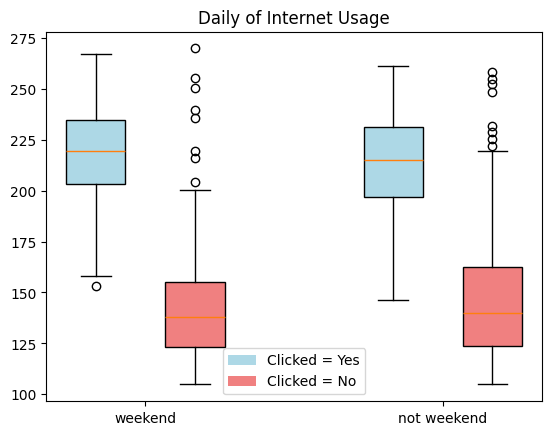

In [41]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
df_box = {}

uniq_weekend = df_transform['is_weekend'].unique()
uniq_clicked = df_transform['Clicked on Ad'].unique()

labels = [f'clicked {k}' for i in uniq_weekend for k in uniq_clicked]

for i in uniq_weekend:
  for k in uniq_clicked:
    get_dat = df_transform[(df_transform['is_weekend'] == i) & (df_transform['Clicked on Ad'] == k)]
    df_box[f'{i}_{k}'] = get_dat['Daily Internet Usage']

all_data = df_box.values()
bp = plt.boxplot(
    all_data,
    positions=[1,2,4,5],
    labels = labels,
    widths=0.6,
    patch_artist=True
)


# clicked = yes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][2].set_facecolor('lightblue')

# clicked = no
bp['boxes'][1].set_facecolor('lightcoral')
bp['boxes'][3].set_facecolor('lightcoral')

plt.xticks([1.5,4.5],['weekend','not weekend'])


plt.legend(
    handles=[
        Patch(facecolor='lightblue', label='Clicked = Yes'),
        Patch(facecolor='lightcoral', label='Clicked = No')
    ]
)
plt.title('Daily of Internet Usage')
plt.show()

Based on the boxplots, users who clicked the advertisement generally exhibit higher daily internet usage than those who did not click. In contrast, the distributions of daily internet usage during weekends and non-weekends are very similar within each click category, suggesting that weekend status has little influence on internet usage. Overall, click behavior appears to be more strongly associated with daily internet usage than whether the observation occurred on a weekend or a non-weekend.

#### b. Daily spent on the website between weekend and not weekend based clicked or not clicked

/tmp/ipykernel_4038/863878233.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


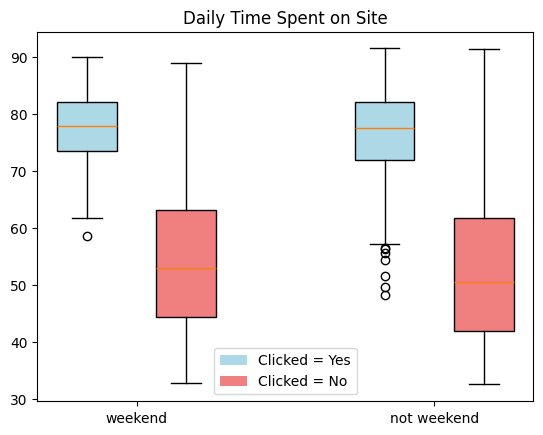

In [42]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
df_box = {}

uniq_weekend = df_transform['is_weekend'].unique()
uniq_clicked = df_transform['Clicked on Ad'].unique()

labels = [f'clicked {k}' for i in uniq_weekend for k in uniq_clicked]

for i in uniq_weekend:
  for k in uniq_clicked:
    get_dat = df_transform[(df_transform['is_weekend'] == i) & (df_transform['Clicked on Ad'] == k)]
    df_box[f'{i}_{k}'] = get_dat['Daily Time Spent on Site']

all_data = df_box.values()
bp = plt.boxplot(
    all_data,
    positions=[1,2,4,5],
    labels = labels,
    widths=0.6,
    patch_artist=True
)


# clicked = yes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][2].set_facecolor('lightblue')

# clicked = no
bp['boxes'][1].set_facecolor('lightcoral')
bp['boxes'][3].set_facecolor('lightcoral')

plt.xticks([1.5,4.5],['weekend','not weekend'])


plt.legend(
    handles=[
        Patch(facecolor='lightblue', label='Clicked = Yes'),
        Patch(facecolor='lightcoral', label='Clicked = No')
    ]
)
plt.title('Daily Time Spent on Site')
plt.show()

Based on boxplots:
- Indicates that there're difference in daily time spent on site between user clicked and did not clicked.
- But, seems status of day (weekend or not weekend) is little influence for daily time spent on site

#### c. Influence of Length of advertisment based on decision clicked or not

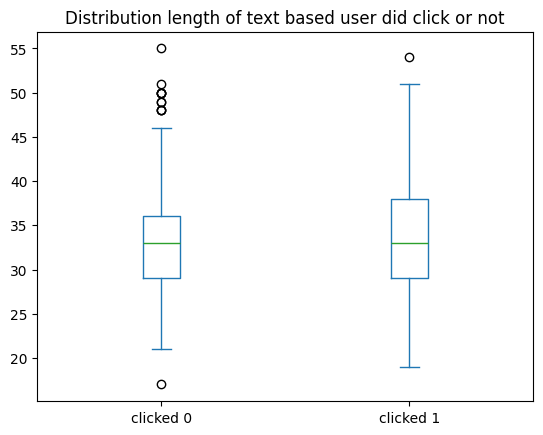

In [43]:
df_box_length = {}
for i in uniq_clicked:
  get_dat = df_transform[df_transform['Clicked on Ad'] == i]['lenght_text']
  df_box_length[f'clicked {i}'] = get_dat

df_box_length = pd.DataFrame(df_box_length).plot(kind='box',title='Distribution length of text based user did click or not')

Based on the boxplot, the distribution of length of advertisment between users click or did not click seems similar, it show that both median have similar value. So the lentgth of advertisment is little influence on decision user click or not

### Build Classification Model

##### Check Distribution of target variable

In [44]:
df_transform['Clicked on Ad'].value_counts()

,count
Clicked on Ad,
0,500
1,500


Based ont table, we can see that total of clicked yes or no is similar, so this indicated the dataset is balanced

##### Split Dataset

In [45]:
from sklearn.model_selection import train_test_split
df_final = df_transform.copy()
X_col = [i for i in df_final.columns.tolist() if i != 'Clicked on Ad' and i != 'timestamp']
y_col = 'Clicked on Ad'
# subset
X = df_final[X_col]
y = df_final[y_col]

# splt
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#validation
X_train_final,X_val,y_train_final,y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)



we use stratify to keep distribua=tion of y is same in different splitting resutl,

##### Logistic Regression

One of classification model in Machine Learninf is Logistic Regression. Logistic regression is classification model predicting binary class label. Logistic regression assume there're linear relationship between input variable and log-odds target variable. The log-odd will convert to probability using sigmoid function

When we have discrete variable, the assignment of label class is arbiatrary. But, the coommon use is we assingn 0 for absence of something label.

Sigmoid function

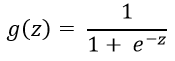

###### Hypotesis Function

Hypotesys function in logistic regression can be written as :

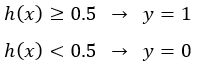

The default threshold is 0.5. We can change the threshold based on work case, for example detecting disease or we want decrease possible of false positive

###### Choose feature

Before we fit model into training and validation set, we choose first the variable that we will used for this case. Before first we want decrease multicolinearity between features, so the variables used is not redundant

In [46]:
df_final.columns.tolist()

['Daily Time Spent on Site',
 'Age',
 'Area Income',
 'Daily Internet Usage',
 'Ad Topic Line',
 'City',
 'Male',
 'Country',
 'Timestamp',
 'Clicked on Ad',
 'hour',
 'weekday',
 'is_weekend',
 'lenght_text']

Based on column in this dataset, we selected the following variables
1. Daily time spend on site
2. Age
3. Area income
4. Daily Internet Usage
5. Gender
6. Is_weekend
7. Length_text

In [47]:
df_final['Country'].nunique()

237

So we decided not selected country because this variable has high cardinality. So the each country will have total_rows/237  =  1000/237, 4 data/row each of country which is can lead overfitting (high bias)

In [48]:
X_col_logistic = [
    'Daily Time Spent on Site',
    'Age',
    'Area Income',
    'Daily Internet Usage',
    'Male',
    'is_weekend',
    'lenght_text'
]

y_col_logistic = 'Clicked on Ad'


###### Transform column


In [49]:
X_train_final_scaled = X_train_final[X_col_logistic].copy()
X_val_scaled = X_val[X_col_logistic].copy()

# scaled
numeric =  [i for i in X_train_final_scaled.columns.tolist() if X_train_final_scaled[i].nunique() > 2]
binary = [i for i in X_train_final_scaled.columns.tolist() if X_train_final_scaled[i].nunique() == 2]



In [50]:
X_val_scaled[binary].head()

,Male,is_weekend
745,0,0
917,1,0
993,1,0
483,1,0
880,1,1


Based on the result, the binary variables has already in numeric-form type so we dont transform these column again

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_final_scaled[numeric] = scaler.fit_transform(X_train_final_scaled[numeric])
X_val_scaled[numeric] = scaler.transform(X_val_scaled[numeric])

In [52]:
X_train_final_scaled.columns.tolist()

['Daily Time Spent on Site',
 'Age',
 'Area Income',
 'Daily Internet Usage',
 'Male',
 'is_weekend',
 'lenght_text']

##### Train Model

###### a. Cost function in logistic regression

recall linear regression to predicting y we can write the formula:

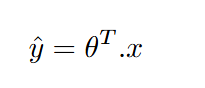

The graphic theta vs cost function will be like this

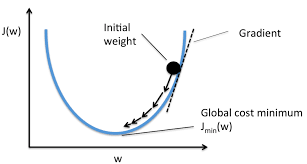

In logistic regression we convert it into probability so the formula will be =

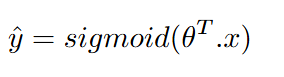

The graphic result

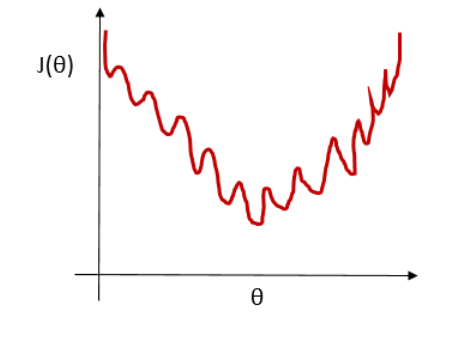

Based on the picture, Because of the non-convex shape, gradient descent may converge to a local minimum rather than the global minimum.

So the cost function in logistic regression

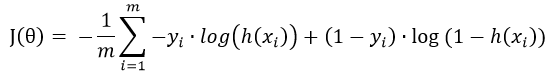



###### b. Mini Batch Gradient Descent

In [53]:
import numpy as np


class LogisticRegression:
  def __init__(self,x_train,x_val,y_train,y_val):
    self.x_train = x_train
    self.x_val = x_val
    self.y_train = y_train
    self.y_val = y_val


  def predict(self,theta,x):
    y_pred = x @ theta.T

    prob_y_pred = 1/(1+np.exp(-y_pred))

    return prob_y_pred

  def loss(self,y_true,y_pred):
    # m
    m = len(y_true)
    # avoid inf when log(0)
    y_pred = np.clip(y_pred,1e-15,1-(1e-15))
    # reshape
    y_true = np.array(y_true).reshape(-1,1)
    loss = (-1/m)*np.sum(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

    return loss

  def mini_batch_gradient_descent(self,learning_rate,batch_size=32,epoch = 7):
    # add intercept
    size_train = self.x_train.shape[0]
    size_val = self.x_val.shape[0]
    X_train_base = np.c_[np.ones((size_train,1)),self.x_train.to_numpy()]
    X_val_arr = np.c_[np.ones((size_val,1)),self.x_val.to_numpy()]
    y_train_base = self.y_train.to_numpy()

    # init theta
    theta = np.zeros((1,X_train_base.shape[1]))

    lr = learning_rate


    epoch_loss_train = []
    epoch_loss_val = []
    for i in range(epoch):

      # shuffle train
      idx_shuffle = np.random.permutation(X_train_base.shape[0])
      X_train_arr = X_train_base[idx_shuffle]
      y_train_arr = y_train_base[idx_shuffle]

      for j in range(0,X_train_arr.shape[0],batch_size):

        # get data batch
        X_batch_arr = X_train_arr[j:j+batch_size]
        y_batch_arr = y_train_arr[j:j+batch_size].reshape(-1,1)

        y_predict_train_arr = self.predict(theta,X_batch_arr)

        # error

        error = y_predict_train_arr -  y_batch_arr

        # gradient
        gradient = error.T @ X_batch_arr  / len(y_batch_arr)

        # update theta
        theta = theta - lr * gradient

      # train and val per epoch

      y_full_pred_train = self.predict(theta,X_train_arr)
      y_full_pred_val = self.predict(theta,X_val_arr)

      loss_train = self.loss(y_train_arr,y_full_pred_train)
      loss_val = self.loss(self.y_val,y_full_pred_val)

      epoch_loss_train.append(loss_train)
      epoch_loss_val.append(loss_val)

    return theta,epoch_loss_train,epoch_loss_val










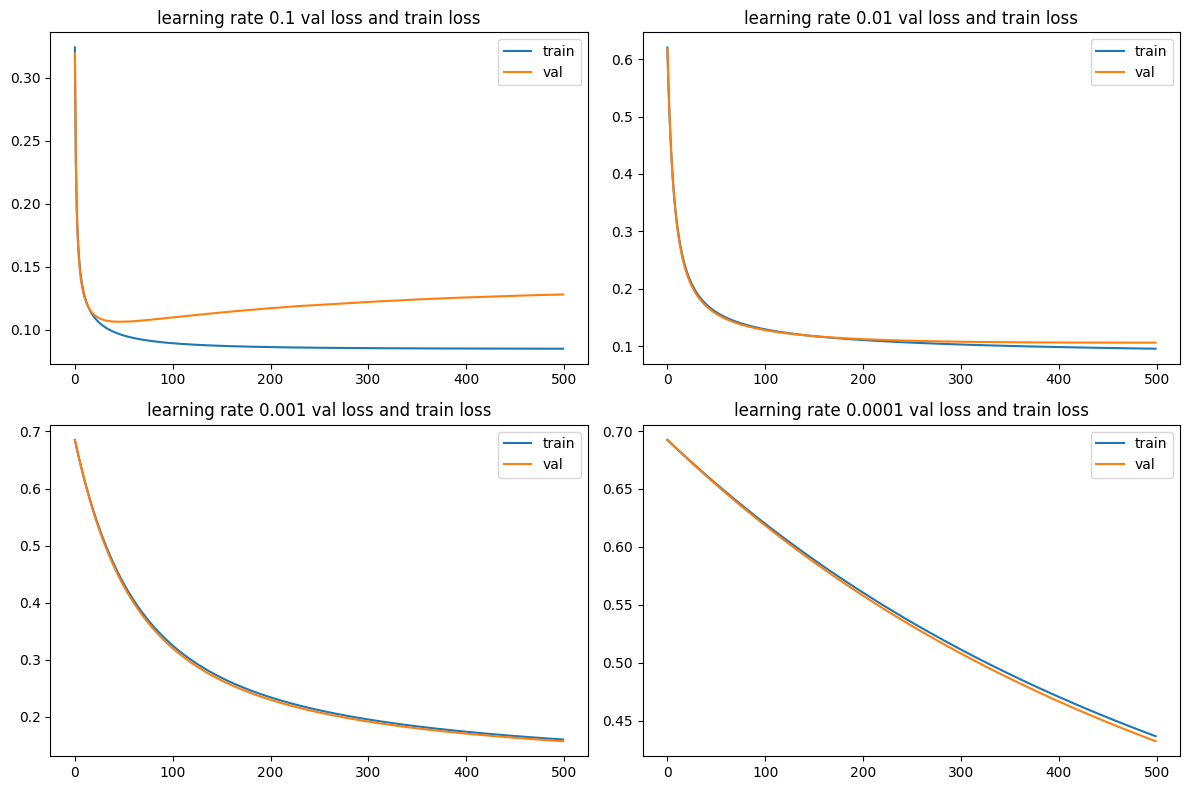

In [54]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(2,2,figsize=(12,8))
ax = ax.ravel()
for i,j in enumerate([0.1,0.01,0.001,0.0001]):
  LogisticRegression_ad = LogisticRegression(X_train_final_scaled,X_val_scaled,y_train_final,y_val)
  finaL_theta,epoch_train_loss,epoch_val_loss = LogisticRegression_ad.mini_batch_gradient_descent(j,epoch=500)
  ax[i].plot(epoch_train_loss,label='train')
  ax[i].plot(epoch_val_loss,label='val')
  ax[i].legend()
  ax[i].set_title(f"learning rate {j} val loss and train loss")

plt.tight_layout()

###### c. Result

Based on the picture with number of epoch 500 and using different learning rate (0.1,0.01,0.001, and 0.0001) seems learning rate 0.01 become the best performance for training the logistic regression model in this dataset giving the best stability between validation and training (stay close each other).

In [55]:
LogisticRegression_ad = LogisticRegression(X_train_final_scaled,X_val_scaled,y_train_final,y_val)
finaL_theta,epoch_train_loss,epoch_val_loss = LogisticRegression_ad.mini_batch_gradient_descent(0.01,epoch=500)

In [73]:
print(finaL_theta)
print(X_train_final_scaled.columns.tolist())

[[ 0.97629951 -2.47585385  1.05153756 -1.4341814  -2.09144196 -0.03996999
   0.43236663 -0.20857283]]
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'is_weekend', 'lenght_text']


#### Evaluation metrics

Recall that in training model we find error using following formula :

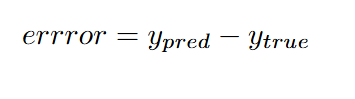

In logistic regression, y_pred is probability and y_true is class label. So when one row y_true = 1 and y_pred = 0.3 , the error will be  = -0.7 so the class label seems predict 0 rather than 1. And then using Mini BGD we find optimum theta using some hyperparameter and get generalization resul seems good using 0.01.

The next thing after we train the model, we want evaluate classfication model on Unseen data using following metrics:

1. Confusion matrix
2. accuracy
3. precision
4. recall
5. f1-score
6. ROC-AUC`


##### a. Confusion Matrix

Table used to evaluate a classficaton model by comparing actual class label and predicted class label

In [56]:
# scaled test
from sklearn.preprocessing import StandardScaler
X_test_scaled = X_test[X_col_logistic].copy()
X_test_scaled[numeric] = scaler.transform(X_test_scaled[numeric])
# add ubterception
X_test_scaled = np.c_[np.ones((X_test_scaled.shape[0],1)),X_test_scaled]

In [57]:
# predict
LogisticRegression_eval_test = LogisticRegression(X_train_final_scaled,X_test_scaled,y_train_final,y_test)

y_test_predict_prob = LogisticRegression_eval_test.predict(finaL_theta,X_test_scaled)
y_test_predict_prob[:5]

array([[0.99974876],
       [0.01160721],
       [0.03087684],
       [0.0159929 ],
       [0.99982867]])

After we predicting y (clicked on ad) using some features in test dataset, we convert them into discrete class label by selecting threshold value and make a decision about class label based on threshold. The threshold value can be changed based on objective of model (sensitive particular class or balanced binary classification)

In [58]:
y_pred_test = (y_test_predict_prob >= 0.5).astype(int)
y_pred_test[:5]

array([[1],
       [0],
       [0],
       [0],
       [1]])

and then build confusion matrix table, there're four items such as
1. true positive (predicted class label 1 but right after comparing true label)
2. false positive
3. true negative (predicted class label 0 but right after comparing true label)
4. false negative



In [59]:
df_confusion = {
    "TP":0,
    "FN":0,
    "FP":0,
    "TN":0

}

for true,pred in zip(y_test,y_pred_test):
  if true == 1 and pred == 1:
    df_confusion["TP"] += 1
  elif true == 1 and pred == 0:
    df_confusion["FN"] += 1
  elif true == 0 and pred == 1:
    df_confusion["FP"] += 1
  else:
    df_confusion["TN"] += 1

arr_confusinon = [
    [df_confusion["TP"],df_confusion["FN"]],
    [df_confusion["FP"],df_confusion["TN"]]
]

result_confusion = pd.DataFrame(arr_confusinon,columns=["predicted 1","predicted 0"],index=["true 1","true 0"])
result_confusion

,predicted 1,predicted 0
true 1,97,3
true 0,1,99


Based on table 95 record model can predicted true class label 1 and only 5 model failed to predicted class label 1. and also model is succesfully predicted all class label 0

##### b. Acurracy

Metrict to find proportion all correctly (true) for both classes among all sample. the formula

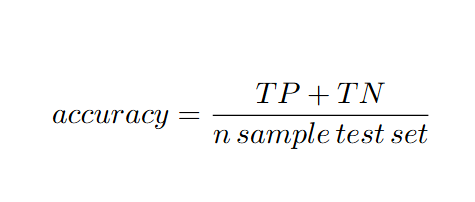

In [60]:
accuracy = ((df_confusion["TP"] + df_confusion["TN"]) / len(y_pred_test)) * 100
print(f"the accuracy of the model is {accuracy} %")

the accuracy of the model is 98.0 %


##### c. Precision

Metrics used to find probability of correctly predicting class lable positive(1) from all model predicting class label 1 regadless true and false. The formula

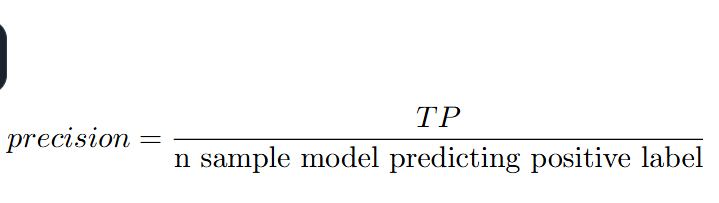

In [61]:
all_positive_pred = y_pred_test[y_pred_test == 1]
precision = (df_confusion['TP']/len(all_positive_pred))*100
print(f"precision is {precision} %")

precision is 98.9795918367347 %


##### c. Recall

Metrics used to find probability of corectly predict true label from all actual true label

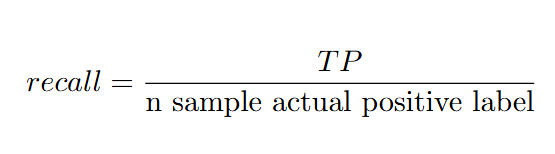

In [62]:
all_actual_true = y_test[y_test == 1]

recall = (df_confusion['TP']/len(all_actual_true))*100
print(f"recall is {recall} %")

recall is 97.0 %


##### d. F1-Score

Metric used to combine precision and recall into one value, measure balance between precision and recall

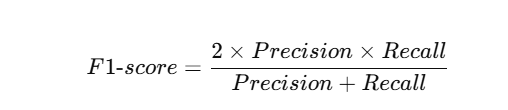



In [63]:
f1_score = (2*precision*recall)/(precision+recall)

print(f"f1-score : {f1_score }")

f1-score : 97.97979797979798


Based on the f1-score result, with high f1-score, the model has excellent performance for predicting positive class label

##### e. ROC-AUC

Measure how well model separate between 0 and 1 using different threshold value.
1. ROC- model performaces accross different threshold value
2. AUC- Area under curve from all ROC point

To make ROC, We should measure two metric
1. TPR (true positive rate)/ recall
2. FPR (false positive rate) (proportion how large actual negative sample  incorectyl classified as  positive label)

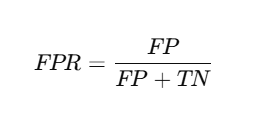

In [64]:
# all threshold
th = np.linspace(0,1,101)

def confusion_matrix(y_test,y_pred):
  confusion = {
      'TP':0,
      'FN':0,
      'FP':0,
      'TN':0
  }

  for true, pred in zip(y_test,y_pred):
    if true == 1 and pred == 1:
      confusion['TP'] +=1
    elif true == 1 and pred == 0:
      confusion['FN'] +=1
    elif true == 0 and pred == 1:
      confusion['FP'] +=1
    elif true == 0 and pred == 0:
      confusion['TN'] +=1
  return confusion



array_roc = []
for i in th:
  y_pred_based_th = (y_test_predict_prob >= i).astype(int)

  # confusion matrix
  confusion_th = confusion_matrix(y_test,y_pred_based_th)

  # recall
  recall  =  confusion_th['TP']/len(y_test[y_test == 1])

  # fpr
  fpr = confusion_th['FP']/len(y_test[y_test == 0])

  array_roc.append([i,recall,fpr])

df_roc = pd.DataFrame(array_roc,columns=['threshold','recall','fpr'])
df_roc


,threshold,recall,fpr
0,0.00,1.00,1.00
1,0.01,1.00,0.87
2,0.02,1.00,0.49
3,0.03,0.99,0.36
4,0.04,0.99,0.27
...,...,...,...
96,0.96,0.87,0.00
97,0.97,0.84,0.00
98,0.98,0.82,0.00
99,0.99,0.79,0.00


And then plot them with x-axis (fpr) and y-axis(recall)

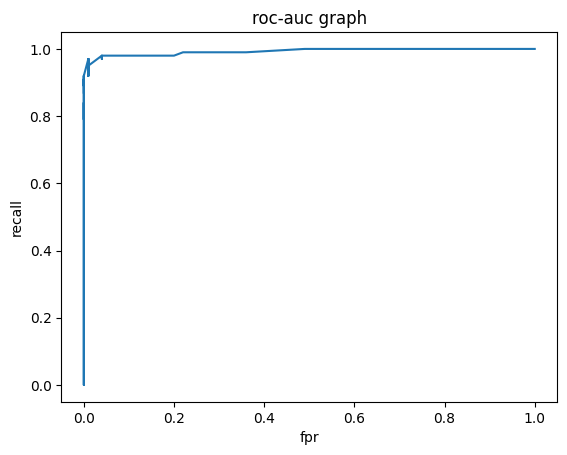

In [65]:
import matplotlib.pyplot as plt
sort_df_roc = df_roc.sort_values(by='fpr')
plt.plot(sort_df_roc['fpr'],sort_df_roc['recall'])
plt.xlabel('fpr')
plt.ylabel('recall')

plt.title('roc-auc graph')
plt.show()

and then we measure area under curve using trapesium approach

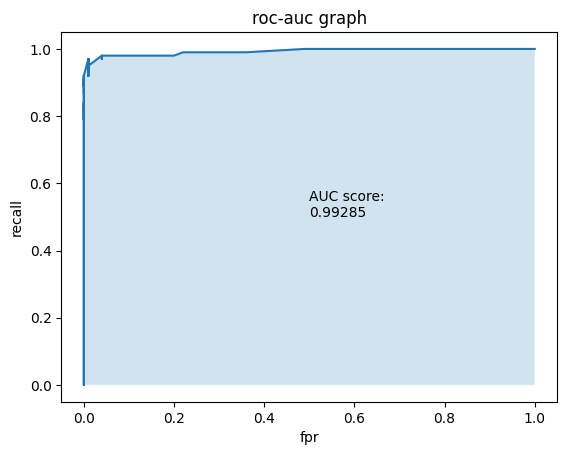

In [66]:
auc_score = np.trapezoid(
    sort_df_roc['recall'],
    sort_df_roc['fpr']
)


import matplotlib.pyplot as plt
sort_df_roc = df_roc.sort_values(by='fpr')
plt.plot(sort_df_roc['fpr'],sort_df_roc['recall'])
plt.xlabel('fpr')
plt.ylabel('recall')

plt.title('roc-auc graph')

plt.fill_between(
    sort_df_roc['fpr'],
    sort_df_roc['recall'],
    alpha=0.2
)

# akses feature yang sudah digambar
ax = plt.gca()
x_min,x_max = ax.get_xlim()
y_min,y_max = ax.get_ylim()

midx = (x_max+x_min)/2
midy = (y_min+y_max)/2

ax.text(midx,midx,f"AUC score:\n{auc_score}")

plt.show()


AUC = 0.99235, indicating excellent discrimination capability. The model can effectively separate class 1 from class 0 with very high recall and a very low false positive rate across different threshold values.

In [68]:
print(final_theta)

NameError: name 'final_theta' is not defined